In [2]:
# ==============================================================================
# Cell 1: Libraries and Helper Functions setup
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

# Set visualization style for publication-ready plots
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

def evaluate_and_plot(y_true, y_pred, model, feature_names, title, is_linear=False, color='blue'):
    """
    Evaluates model performance and plots Actual vs Predicted & Feature Importances.
    """
    # 1. Calculate Metrics
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    pcc, p_val = pearsonr(y_true, y_pred)
    
    print(f"\n=== Performance Metrics: {title} ===")
    print(f"R2 Score : {r2:.4f}")
    print(f"PCC      : {pcc:.4f} (p-value: {p_val:.4e})")
    print(f"RMSE     : {rmse:.4f}")
    
    # 2. Setup Figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot A: Scatter Plot (Actual vs Predicted)
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.4, color=color, edgecolor=None, ax=axes[0])
    min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')
    axes[0].set_title(f"{title}: Actual vs. Predicted", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Actual Log2(AUC)")
    axes[0].set_ylabel("Predicted Log2(AUC)")
    axes[0].legend()
    
    # Plot B: Feature Importances / Coefficients
    if is_linear:
        # Extract coefficients for Linear Models (Ridge)
        importances = model.named_steps['ridgecv'].coef_
        imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances, 'Abs_Imp': np.abs(importances)})
        top_features = imp_df.sort_values(by='Abs_Imp', ascending=False).head(15)
        sns.barplot(x='Importance', y='Feature', data=top_features, palette='coolwarm', ax=axes[1])
        axes[1].set_xlabel("Coefficient Value (Impact)")
    else:
        # Extract F-scores for Tree Models (XGBoost)
        importances = model.feature_importances_
        imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        top_features = imp_df.sort_values(by='Importance', ascending=False).head(15)
        sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis', ax=axes[1])
        axes[1].set_xlabel("F-score (XGBoost Importance)")
        
    axes[1].set_title(f"Top 15 Biomarkers / Features", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("")
    
    plt.tight_layout()
    plt.show()

In [3]:
# ==============================================================================
# Cell 2: Load the Processed Dataset
# ==============================================================================
print("Loading the fully processed dataset...")

# Update the file name if you saved it differently
DATA_PATH = "PRISM_DepMap_Final_Processed_Dataset.csv" 
final_dataset = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully!")
print(f"Total shape: {final_dataset.shape}")

# Ensure all features (everything except IDs and target) are float
feature_cols = [c for c in final_dataset.columns if c not in ['depmap_id', 'broad_id', 'log2_auc', 'auc']]
final_dataset[feature_cols] = final_dataset[feature_cols].astype(float)

Loading the fully processed dataset...
Dataset loaded successfully!
Total shape: (103050, 566)


Starting Experiment 1: Unseen Cell Lines Split...
Training on 88144 samples, Testing on 14906 samples.
Training XGBoost...

=== Performance Metrics: XGBoost: Unseen Cell Lines ===
R2 Score : 0.7076
PCC      : 0.8420 (p-value: 0.0000e+00)
RMSE     : 0.3109


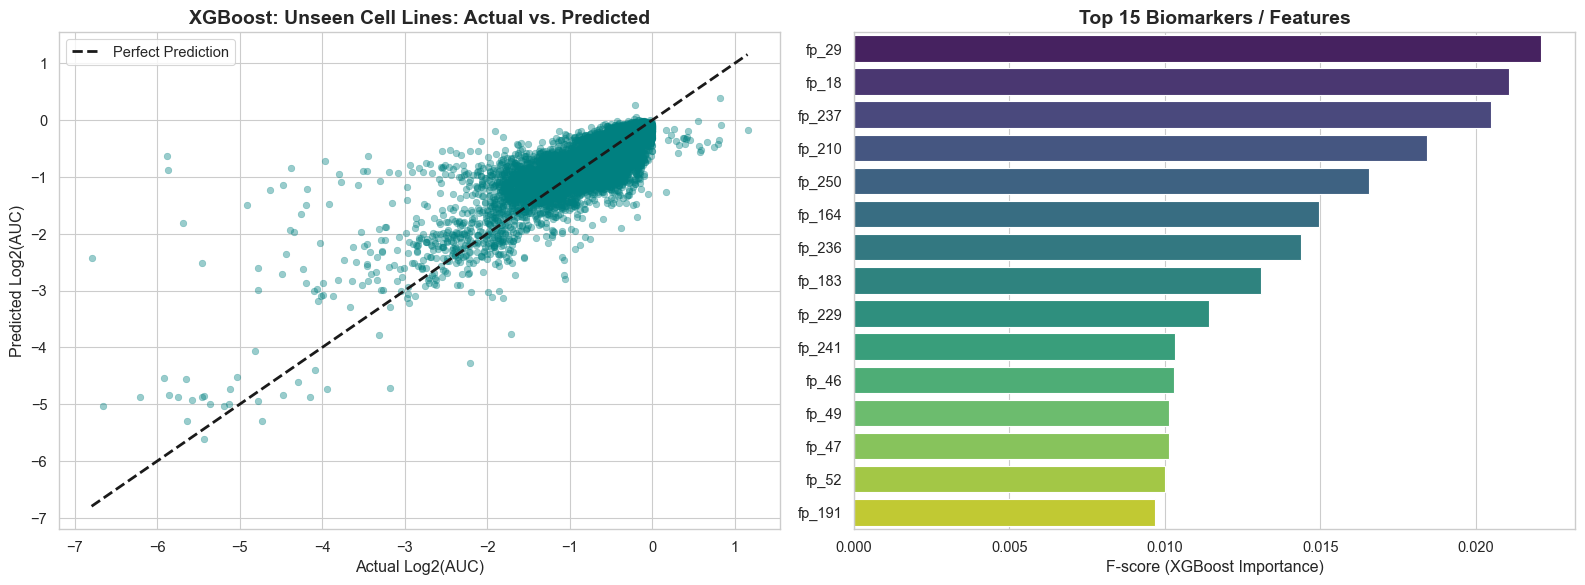

In [7]:
# ==============================================================================
# Cell 4: Experiment 1 - Precision Medicine (Unseen Cell Lines)
# Objective: Train on a subset of cell lines, predict on completely unseen cell lines.
# Model: XGBoost Regressor
# ==============================================================================
print("Starting Experiment 1: Unseen Cell Lines Split...")

X = final_dataset.drop(columns=['depmap_id', 'broad_id', 'log2_auc', 'auc'])
y = final_dataset['log2_auc']
groups_cells = final_dataset['depmap_id'] # Grouping by cell line

# Split data preventing cell line leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups_cells))

X_train_cells, y_train_cells = X.iloc[train_idx], y.iloc[train_idx]
X_test_cells, y_test_cells = X.iloc[test_idx], y.iloc[test_idx]

print(f"Training on {len(X_train_cells)} samples, Testing on {len(X_test_cells)} samples.")

# Initialize and train model
xgb_cells = XGBRegressor(
    random_state=42,
    device='cuda', # Remove if running on CPU
    n_estimators=800,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

print("Training XGBoost...")
xgb_cells.fit(X_train_cells, y_train_cells)

# Evaluate and plot using our helper function
preds_cells = xgb_cells.predict(X_test_cells)
evaluate_and_plot(
    y_true=y_test_cells, 
    y_pred=preds_cells, 
    model=xgb_cells, 
    feature_names=X.columns, 
    title="XGBoost: Unseen Cell Lines", 
    is_linear=False,
    color='teal'
)

Starting Experiment 2: Single-Drug Biomarker Discovery...
Target Drug Selected: BRD-K15179879-001-03-2
Training on 306 biological pathways across 581 cell lines.
Training Ridge Regression Model...

=== Performance Metrics: Ridge: Biomarkers for BRD-K15179879-001-03-2 ===
R2 Score : 0.0230
PCC      : 0.1701 (p-value: 8.5796e-02)
RMSE     : 0.7730


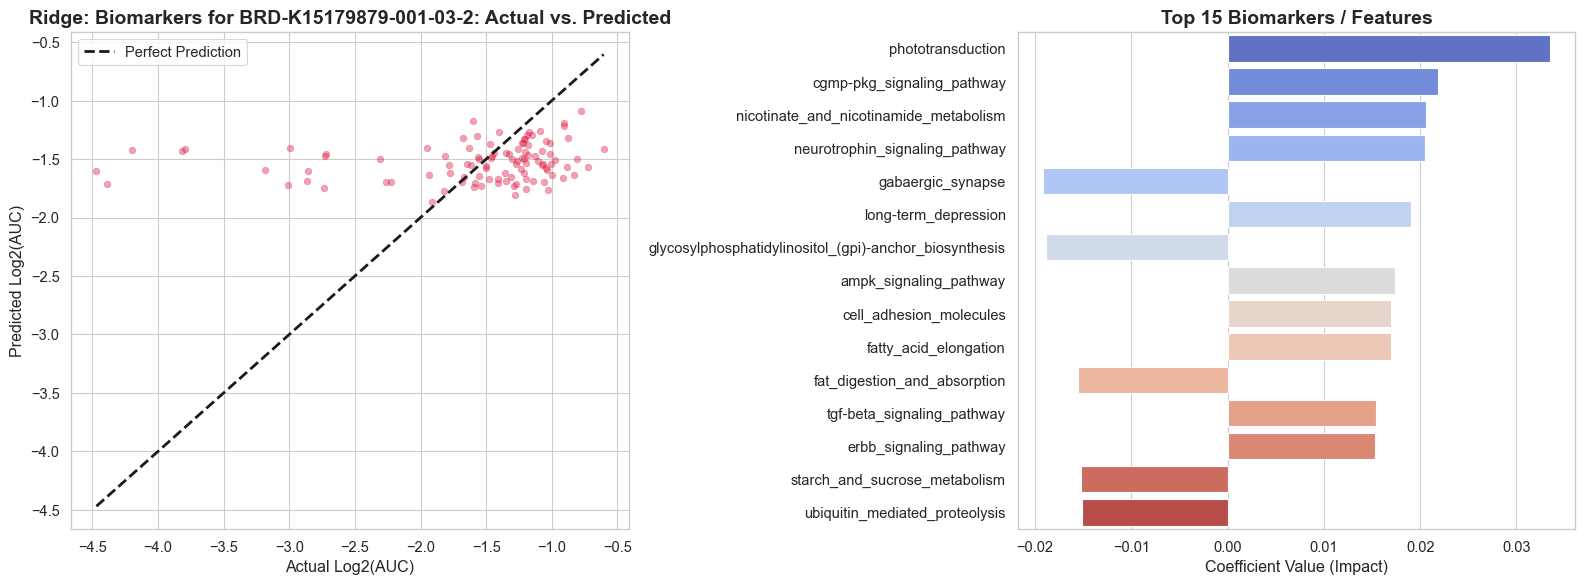

In [5]:
# ==============================================================================
# Cell 5: Experiment 2 - Single-Drug Biological Biomarker Discovery
# Objective: Identify biological pathways responsible for resistance/sensitivity to a specific drug.
# Model: Regularized Linear Model (Ridge Regression)
# ==============================================================================
print("Starting Experiment 2: Single-Drug Biomarker Discovery...")

# 1. Identify the drug with the highest variance (most varied biological response)
drug_stats = final_dataset.groupby('broad_id')['log2_auc'].agg(['count', 'std']).reset_index()
valid_drugs = drug_stats[drug_stats['count'] >= 400]
target_drug = valid_drugs.sort_values('std', ascending=False).iloc[0]['broad_id']

print(f"Target Drug Selected: {target_drug}")

# 2. Filter data and DROP chemical features (Morgan Fingerprints)
single_drug_df = final_dataset[final_dataset['broad_id'] == target_drug].copy()
cols_to_drop = ['depmap_id', 'broad_id', 'log2_auc', 'auc'] + [col for col in single_drug_df.columns if col.startswith('fp_')]

X_bio = single_drug_df.drop(columns=cols_to_drop)
y_bio = single_drug_df['log2_auc']

# 3. Random Split (Since drug is constant, we split cell lines)
X_train_bio, X_test_bio, y_train_bio, y_test_bio = train_test_split(
    X_bio, y_bio, test_size=0.15, random_state=42
)

print(f"Training on {X_train_bio.shape[1]} biological pathways across {len(X_train_bio)} cell lines.")

# 4. Initialize and train a Regularized Linear Model
# Standardization is critical for linear models to ensure fair coefficient comparison
ridge_pipeline = make_pipeline(
    StandardScaler(), 
    RidgeCV(alphas=np.logspace(-3, 3, 100))
)

print("Training Ridge Regression Model...")
ridge_pipeline.fit(X_train_bio, y_train_bio)

# 5. Evaluate and plot
preds_bio = ridge_pipeline.predict(X_test_bio)
evaluate_and_plot(
    y_true=y_test_bio, 
    y_pred=preds_bio, 
    model=ridge_pipeline, 
    feature_names=X_bio.columns, 
    title=f"Ridge: Biomarkers for {target_drug}", 
    is_linear=True,
    color='crimson'
)